In [1]:
pip install scikit-rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.3/631.3 kB 8.2 MB/s eta 0:00:00


In [1]:
import argparse
import numpy as np
import matplotlib.pyplot as plt

# ---- S2P loader (robust option) ----
# Uses scikit-rf to parse S2P properly.
import skrf as rf
import random
import torch
import torch.nn as nn
import torch.optim as optim

import os, glob
from torch.utils.data import Dataset, DataLoader

In [2]:
def load_s21_mag_db_from_s2p(path: str):
    ntwk = rf.Network(path)

    f_hz = ntwk.f  # shape (M,)
    s = ntwk.s     # shape (M, 2, 2), complex

    # S21 is row=1, col=0 in 0-based indexing (port2 <- port1)
    s21 = s[:, 1, 0]
    mag = np.abs(s21)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-12))

    return f_hz.astype(np.float64), mag_db.astype(np.float64)

In [3]:
def resample_to_fixed_grid(f_hz: np.ndarray, y: np.ndarray, n_points: int):
    # Create uniform grid over existing range and interpolate
    f_min, f_max = float(f_hz.min()), float(f_hz.max())
    f_new = np.linspace(f_min, f_max, n_points)
    y_new = np.interp(f_new, f_hz, y)
    return f_new, y_new

In [4]:
def standardize_1d(y: np.ndarray):
    mu = float(y.mean())
    sigma = float(y.std() + 1e-12)
    y_std = (y - mu) / sigma
    return y_std, mu, sigma

In [5]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, latent_channels=16):
        super().__init__()
        # Input: (B, C=1, N)

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/2

            nn.Conv1d(8, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/4

            nn.Conv1d(16, latent_channels, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/8
        )

        # Pooling head for fixed-length features: (B, C, L) -> (B, C)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Decoder (mirror)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),  # N/8 -> N/4
            nn.Conv1d(latent_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode="nearest"),  # N/4 -> N/2
            nn.Conv1d(16, 8, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode="nearest"),  # N/2 -> N
            nn.Conv1d(8, 1, kernel_size=9, padding=4),
            # No activation: reconstruction in standardized space can be any real number
        )

    def encode(self, x, return_map: bool = False):
        """
        Returns:
          - latent map z with shape (B, latent_channels, L) if return_map=True
          - pooled feature vector feat with shape (B, latent_channels) otherwise
        """
        z = self.enc(x)  # (B, C, L)
        if return_map:
            return z
        feat = self.pool(z).squeeze(-1)  # (B, C, 1) -> (B, C)
        return feat

    def forward(self, x):
        z = self.enc(x)
        y = self.dec(z)
        return y

In [6]:
def prepare_dataset(s2p_files, n_points=1024):
    signals = []

    for file in s2p_files:
        try:
            freq, mag = load_s21_mag_db_from_s2p(file)
            freq, mag = resample_to_fixed_grid(freq, mag, n_points)
            mag, _, _ = standardize_1d(mag)
            signals.append(mag)
        except:
            continue

    signals = np.array(signals)  # (N_samples, 1024)
    return torch.tensor(signals).float()

In [7]:
def train_model(
    s2p_files,
    checkpoint_dir,
    num_epochs=100,
    lr=1e-3,
    batch_size=16,
    plot_loss=True
):
    import os
    import matplotlib.pyplot as plt
    import torch.optim as optim
    import torch.nn as nn
    from torch.utils.data import DataLoader

    os.makedirs(checkpoint_dir, exist_ok=True)

    # Prepare dataset
    data = prepare_dataset(s2p_files)
    dataset = torch.utils.data.TensorDataset(data)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Model
    model = Conv1DAutoencoder()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()

    training_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for (batch,) in dataloader:
            batch = batch.unsqueeze(1)  # (B, 1, 1024)

            optimizer.zero_grad()

            output = model(batch)

            loss = criterion(output, batch)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        training_losses.append(avg_epoch_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {avg_epoch_loss:.6f}"
        )

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_epoch_loss,
            }, os.path.join(
                checkpoint_dir,
                f'checkpoint_epoch_{epoch+1}.pt'
            ))

    # Plot training loss
    if plot_loss:
        plt.figure(figsize=(10, 5))
        plt.plot(
            range(1, num_epochs + 1),
            training_losses,
            marker='o',
            label='Training Loss'
        )
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title("Autoencoder Training Loss")
        plt.grid(True)
        plt.legend()
        plt.show()

    return model

In [9]:
def train_model(s2p_files,checkpoint_dir, num_epochs=100, lr=1e-3, batch_size=16):

    os.makedirs(checkpoint_dir, exist_ok=True)

    # Prepare dataset
    data = prepare_dataset(s2p_files)
    dataset = torch.utils.data.TensorDataset(data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Model
    model = Conv1DAutoencoder()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0

        for (batch,) in dataloader:

            batch = batch.unsqueeze(1)  # (B, 1, 1024)

            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(dataloader):.6f}")

            # ✅ CHECKPOINT SAVE
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_loss / len(dataloader),
            }, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pt'))

    return model

In [8]:
def test_one_file(model, s2p_path, file, n_points=1024, device="cpu"):
    model = model.to(device)
    model.eval()

    # --- preprocess exactly like training ---
    freq, mag_db = load_s21_mag_db_from_s2p(s2p_path)
    freq_new, mag_db = resample_to_fixed_grid(freq, mag_db, n_points)
    mag_std, mu, sigma = standardize_1d(mag_db)

    x = torch.tensor(mag_std).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,N)

    with torch.no_grad():
        y = model(x)  # reconstruction in standardized space

    y = y.squeeze().cpu().numpy()          # (N,)
    x_np = x.squeeze().cpu().numpy()       # (N,)

    # MSE in standardized space (this matches training loss scale)
    mse_std = float(np.mean((y - x_np) ** 2))

    # Optional: convert back to dB scale for interpretability
    x_db = x_np * sigma + mu
    y_db = y * sigma + mu

    # --- plot ---
    plt.figure()
    plt.plot(freq_new, x_db, label="Original S21 (dB)")
    plt.plot(freq_new, y_db, label="Reconstructed S21 (dB)")
    plt.title(os.path.basename(s2p_path) + f" | MSE(std)={mse_std:.6f}"+f"|{file}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("S21 magnitude (dB)")
    plt.legend()
    plt.show()

    return mse_std, (freq_new, x_db, y_db)

In [9]:
# # continue training later
# checkpoint = torch.load("checkpoint_epoch_21.pt")

# model = Conv1DAutoencoder()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch'] + 1

Traversing directory: /content/drive/MyDrive/Data/MAS Volunteer Study March 2023
Epoch [1/200] Loss: 0.826751
Epoch [2/200] Loss: 0.347530
Epoch [3/200] Loss: 0.100507
Epoch [4/200] Loss: 0.036618
Epoch [5/200] Loss: 0.027360
Epoch [6/200] Loss: 0.024083
Epoch [7/200] Loss: 0.020996
Epoch [8/200] Loss: 0.019156
Epoch [9/200] Loss: 0.017149
Epoch [10/200] Loss: 0.015157
Epoch [11/200] Loss: 0.013636
Epoch [12/200] Loss: 0.012011
Epoch [13/200] Loss: 0.010054
Epoch [14/200] Loss: 0.007998
Epoch [15/200] Loss: 0.006423
Epoch [16/200] Loss: 0.005694
Epoch [17/200] Loss: 0.005024
Epoch [18/200] Loss: 0.004835
Epoch [19/200] Loss: 0.004254
Epoch [20/200] Loss: 0.003988
Epoch [21/200] Loss: 0.003520
Epoch [22/200] Loss: 0.003273
Epoch [23/200] Loss: 0.003202
Epoch [24/200] Loss: 0.002988
Epoch [25/200] Loss: 0.002808
Epoch [26/200] Loss: 0.002735
Epoch [27/200] Loss: 0.002493
Epoch [28/200] Loss: 0.002373
Epoch [29/200] Loss: 0.002295
Epoch [30/200] Loss: 0.002150
Epoch [31/200] Loss: 0.00196

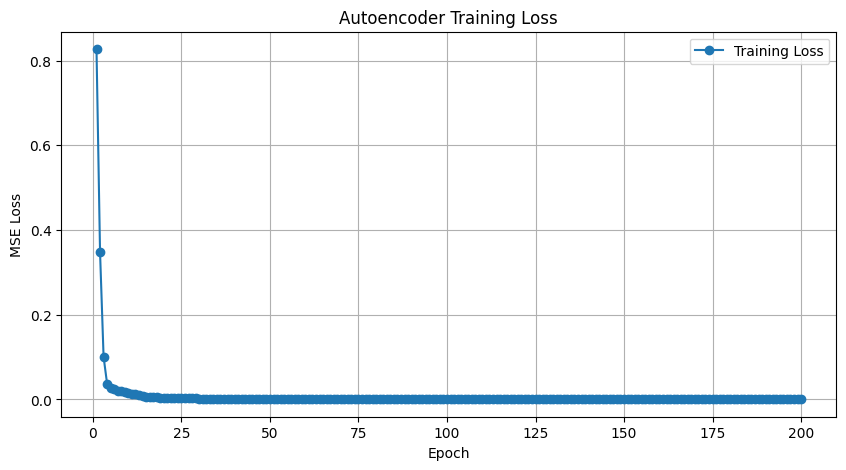

In [10]:
root_dir = '/content/drive/MyDrive/Data/MAS Volunteer Study March 2023'

print(f"Traversing directory: {root_dir}")

s2p_files = []
error_data = []
for dirpath, dirnames, filenames in os.walk(root_dir):
    if 'Beamer' in dirpath:
        continue
    for filename in filenames:
        file_path = os.path.join(dirpath, filename)
        if filename == "Air.s2p":
          continue
        else:
          s2p_files.append(file_path)
checkpoints_dir = '/content/drive/MyDrive/Data/checkpoints/autoencoder/'
model = train_model(s2p_files,checkpoints_dir,200)

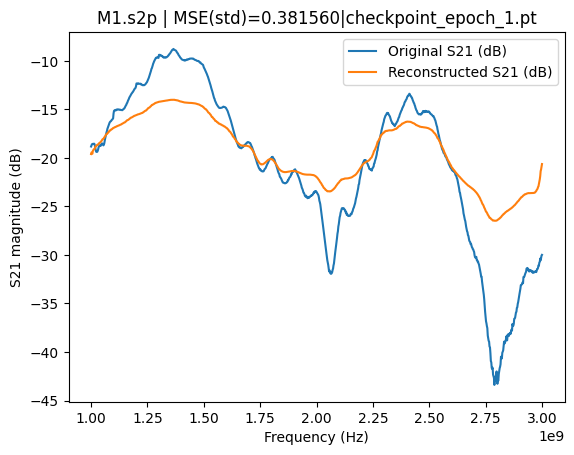

Test MSE (standardized space): 0.3815600275993347


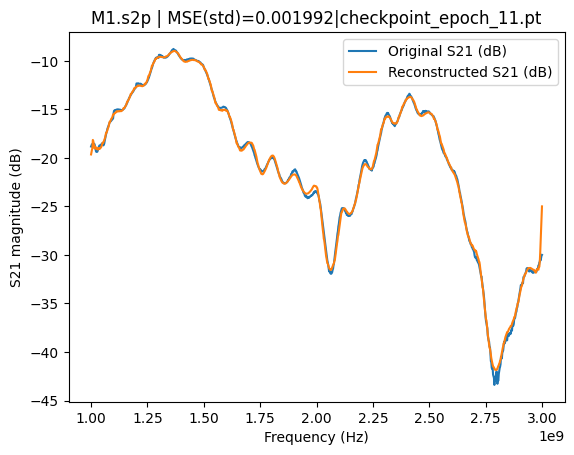

Test MSE (standardized space): 0.0019918966572731733


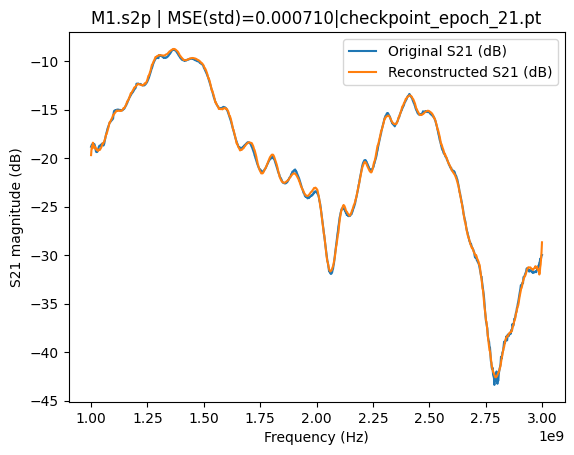

Test MSE (standardized space): 0.0007101178052835166


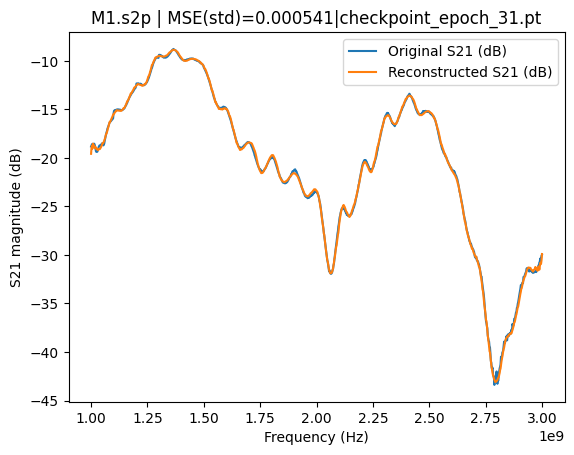

Test MSE (standardized space): 0.0005408262368291616


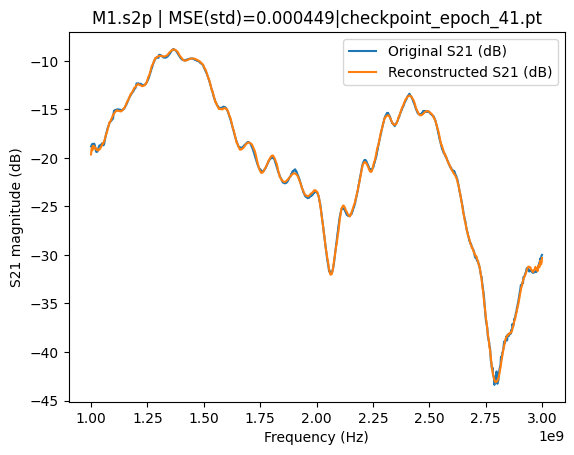

Test MSE (standardized space): 0.0004487969563342631


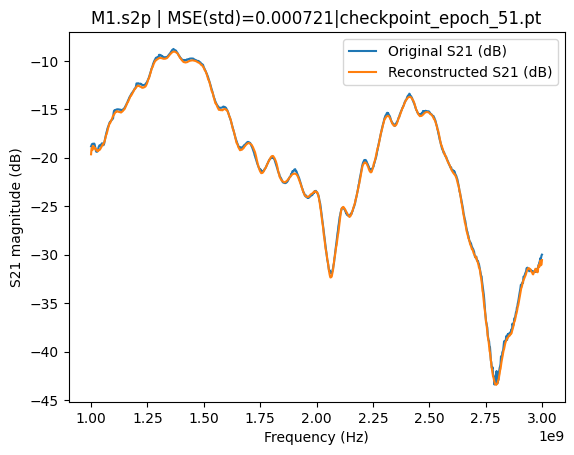

Test MSE (standardized space): 0.0007208106108009815


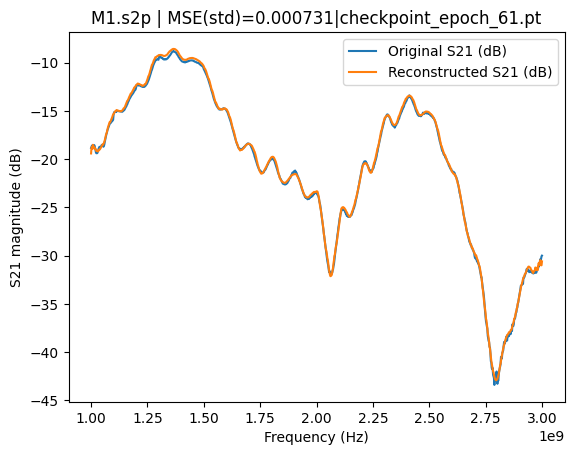

Test MSE (standardized space): 0.0007311179069802165


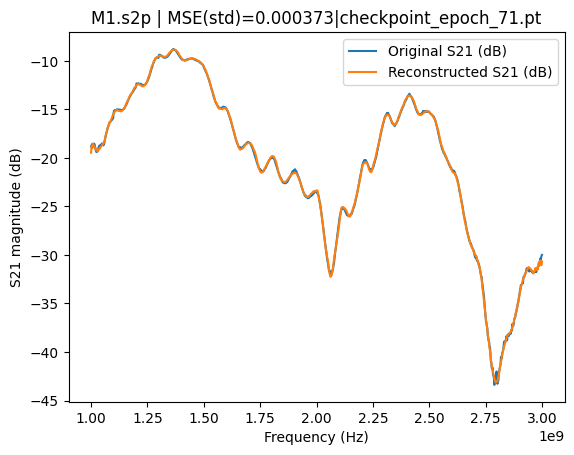

Test MSE (standardized space): 0.00037296119262464345


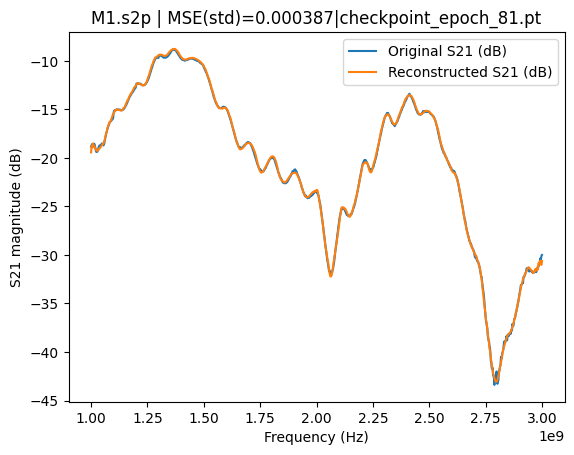

Test MSE (standardized space): 0.0003867736959364265


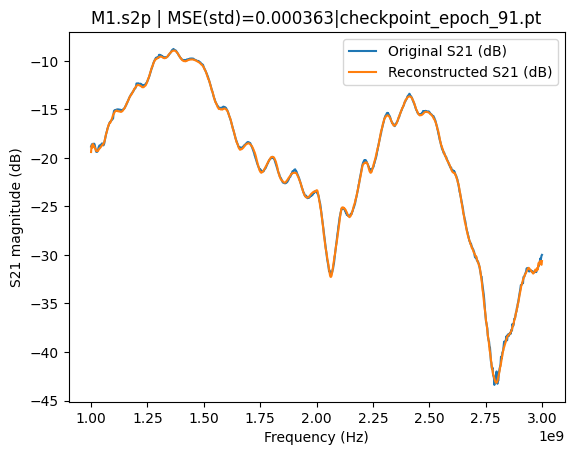

Test MSE (standardized space): 0.0003625608514994383


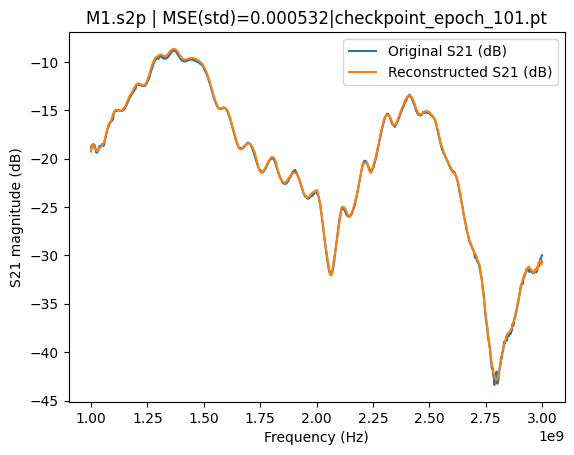

Test MSE (standardized space): 0.0005321433418430388


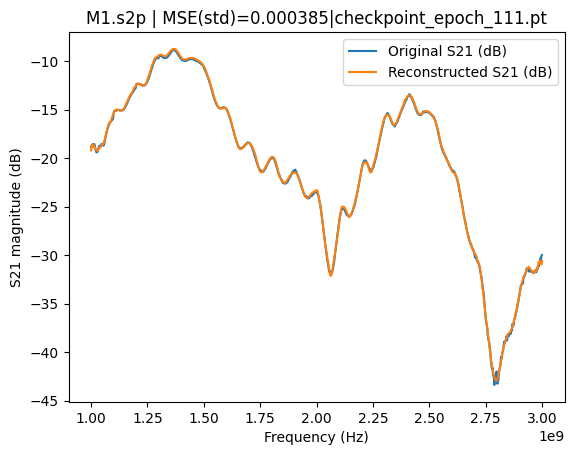

Test MSE (standardized space): 0.0003848327323794365


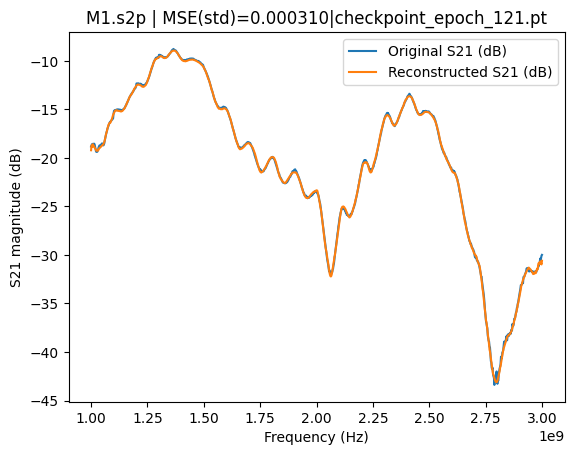

Test MSE (standardized space): 0.00031013006810098886


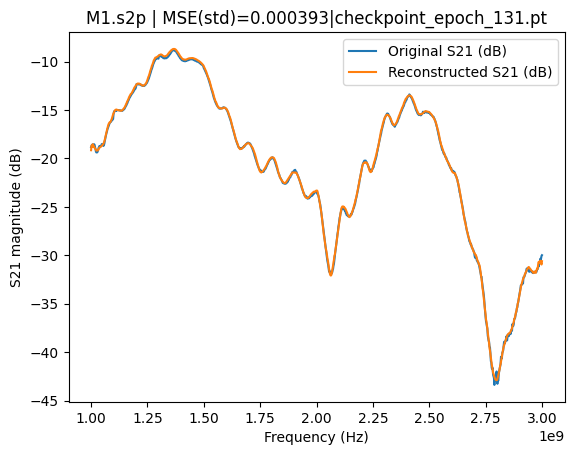

Test MSE (standardized space): 0.0003930806997232139


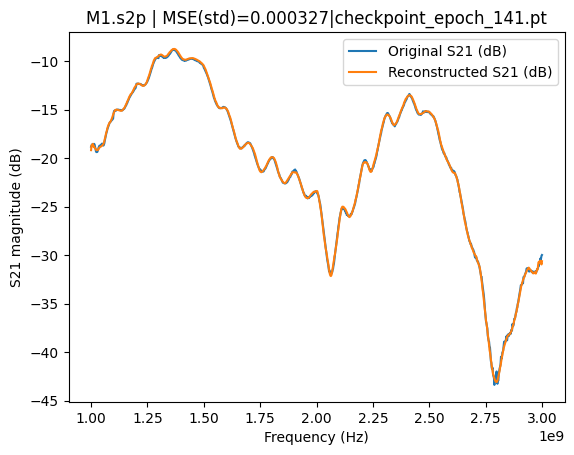

Test MSE (standardized space): 0.0003268131986260414


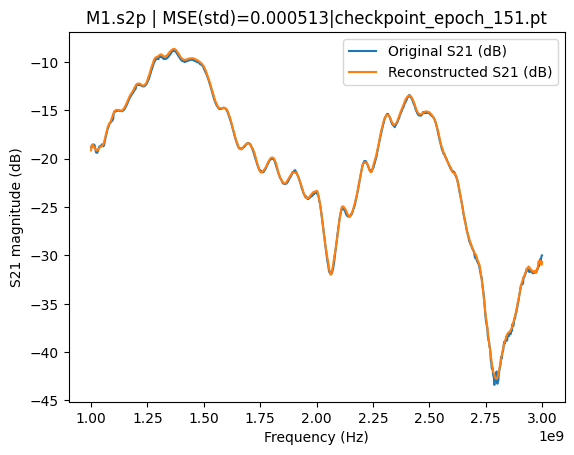

Test MSE (standardized space): 0.0005127809126861393


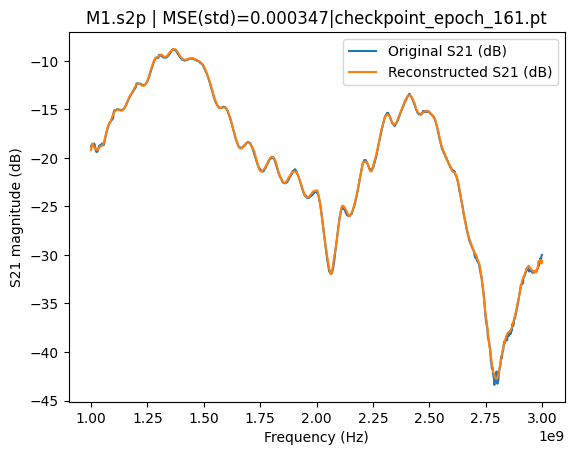

Test MSE (standardized space): 0.00034744886215776205


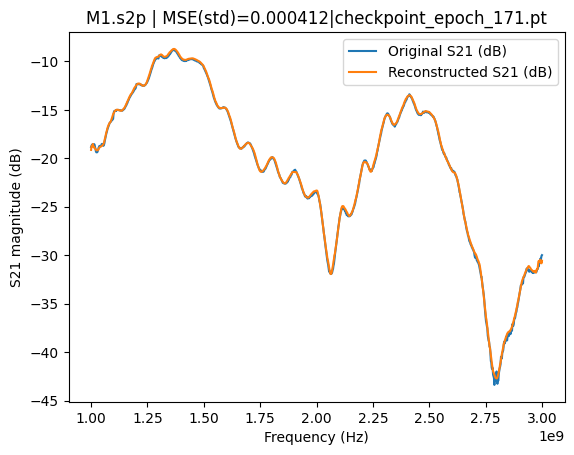

Test MSE (standardized space): 0.00041172720375470817


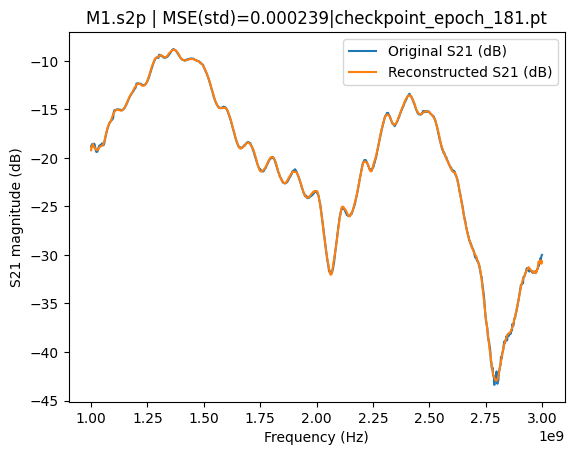

Test MSE (standardized space): 0.00023931649047881365


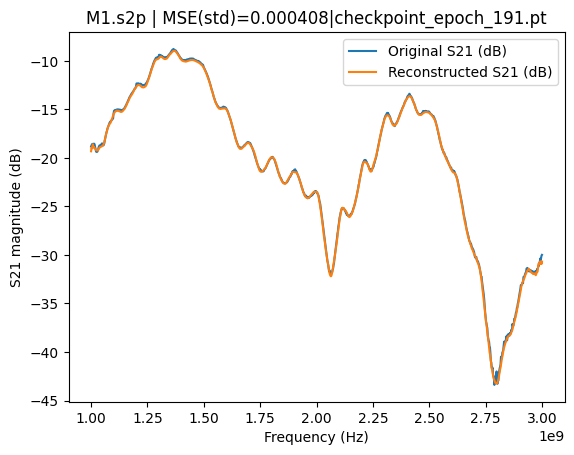

Test MSE (standardized space): 0.00040797816473059356


In [ ]:
checkpoint_path_root = "/content/drive/MyDrive/Data/checkpoints/autoencoder/"
files = []
for file in os.listdir(checkpoint_path_root):
  if file.endswith(".pt"):
    files.append(file)

for file in files:
  checkpoint_path = checkpoint_path_root+file
  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  model = Conv1DAutoencoder()
  model.load_state_dict(checkpoint["model_state_dict"])

  sample_path = "/content/drive/MyDrive/Data/MAS Volunteer Study March 2023/Volunteer 1/nanoVNA/Bandstop S1/M1.s2p"
  mse, (f, x_db, y_db) = test_one_file(model, sample_path,file)
  print("Test MSE (standardized space):", mse)

In [ ]:
root_dir = '/content/drive/MyDrive/Data/MAS Volunteer Study March 2022'

print(f"Traversing directory: {root_dir}")

s2p_files = []
error_data = []
for dirpath, dirnames, filenames in os.walk(root_dir):
    if 'Beamer' in dirpath:
        continue
    for filename in filenames:
        file_path = os.path.join(dirpath, filename)
        if filename == "Air.s2p":
          continue
        else:
          s2p_files.append(file_path)



Traversing directory: /content/drive/MyDrive/Data/MAS Volunteer Study March 2022


In [ ]:
results = [["model","MSE","f_db"]]
models = ["standard","de_gauss","de_mask","de_comb"]
chk_point_a = "/content/drive/MyDrive/Data/checkpoints/autoencoder/checkpoint_epoch_191.pt"
chk_point_de_gauss = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/gaussian/checkpoint_epoch_191.pt"
chk_point_de_mask = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/mask/checkpoint_epoch_191.pt"
chk_point_de_comb = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/combined/checkpoint_epoch_191.pt"

test = random.sample(s2p_files, 100)

for model_name in models:

  if model_name == "standard":
    checkpoint_path = chk_point_a
  elif model_name == "de_gauss":
    checkpoint_path = chk_point_de_gauss
  elif model_name == "de_mask":
    checkpoint_path = chk_point_de_mask
  elif model_name == "de_comb":
    checkpoint_path = chk_point_de_comb

  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  model = Conv1DAutoencoder()
  model.load_state_dict(checkpoint["model_state_dict"])

  for path in test:
    sample_path = path
    try:
      mse, (f, x_db, y_db) = test_one_file(model, sample_path,file)
      results.append([model_name,mse,(f, x_db, y_db)])
    except:
      error_data.append(file)
      continue

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd

# 'results' list is available from the kernel state

# Extract headers and data
df_columns = results[0]
df_data = results[1:]

# Create DataFrame
results_df = pd.DataFrame(df_data, columns=df_columns)

In [ ]:
average_mse_by_model = results_df.groupby('model')['MSE'].mean()
print("Average MSE grouped by model:")
print(average_mse_by_model)

Average MSE grouped by model:
model
de_comb     0.037676
de_gauss    0.027966
de_mask     0.038081
standard    0.031342
Name: MSE, dtype: float64
